# Lab 6: Creating SSS Time Series
In this notebook, we will generate and plot a timeseries of sea surface salinity from a collection of files.

**Import modules for this notebook**

In [3]:
# import the numpy, matplotlib, netcdf4 and os modules
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import os

### Set paths to your local and external folders

In [36]:
# define the path to your local folder
local_folder = '/Users/mike/Documents/Teaching/Courses/MS 274/Labs/Lab 7'

# define the path to your data folder
data_folder = '/Users/mike/Documents/Teaching/Courses/MS 274/Labs/Lab 7'

# set the longitude and latitude of the location
site_longitude = -125
site_latitude = 37

## Step 1: Download SSS files
Using the "Downloading Data from PODAAC Cloud" notebook, download all monthly SSS values from 2017 and 2018.

## Step 2: Make a list of all files for this dataset
Search the current directory for all nc files

In [11]:
# create an empty list to store the files
nc_files = []

# write a for loop to loop through the files
for file_name in os.listdir(data_folder+'/Raster Data'):
    # if the file is an nc file 
    if 'SMAP' in file_name:
        nc_files.append(file_name)

# sort the file list
nc_files.sort()

# print the number of files that are found
print('Found '+str(len(nc_files))+' files')

Found 24 files


## Step 3: Make an array of dates

In [16]:
# make an empty list for strings storing the date
date_list = []

# loop through the file name
for file_name in nc_files:
    # split the file name and retrieve the year and month strings
    year_str = file_name.split('_')[3][:4]
    month_str = file_name.split('_')[3][4:6]

    # make a string for the middle day of the month (15)
    day_str = '15'

    # join the year, month, and day strings with dashes
    # and add the date string to the date_list
    date_list.append(year_str+'-'+month_str+'-'+day_str)

# convert the date list to array
date_array = np.array(date_list, dtype='datetime64')

## Step 4: Test Opening a NetCDF File

#### Open a file and read in the data

In [21]:
# create a path to the first SSS file
file_path = data_folder+'/Raster Data/'+nc_files[0]
print(file_path)

# open the netCDF file with the nc4.Dataset() method
ds = nc4.Dataset(file_path)

# read in the longitude and latiude variables 
lon = ds.variables['longitude'][:]
lat = ds.variables['latitude'][:]

# read in the sss field
SSS = ds.variables['smap_sss'][:, :]

# close the netCDF file
ds.close()

/Users/mike/Documents/Teaching/Courses/MS 274/Labs/Lab 7/Raster Data/SMAP_L3_SSS_201801_MONTHLY_V5.0.nc


#### Find an SSS value at the location closest to Monterey Bay

In [31]:
# find the closest indices to the site longitude and latitude
lon_index = np.argmin(np.abs(lon-site_longitude))
lat_index = np.argmin(np.abs(lat-site_latitude))

# compute the closest lon and lat
closest_lon = lon[lon_index]
closest_lat = lat[lat_index]

# print the closest lon and lat to the site and 
# compare with the site lons
print(site_longitude, closest_lon)
print(site_latitude, closest_lat)

# print the SSS value at this location
closest_sss = SSS[lat_index, lon_index]
print(closest_sss)

-122 -122.125
36.76 36.875
32.46859


## Step 5: Create a function for SSS
Write a function that will take in a file path and return an SSS value

In [41]:
def read_SSS_from_file(file_path, site_longitude, site_latitude):
    ds = nc4.Dataset(file_path)

    # read in the longitude and latiude variables 
    lon = ds.variables['longitude'][:]
    lat = ds.variables['latitude'][:]
    
    # read in the sss field
    SSS = ds.variables['smap_sss'][:, :]
    
    # close the netCDF file
    ds.close()

    # find the closest indices to the site longitude and latitude
    lon_index = np.argmin(np.abs(lon-site_longitude))
    lat_index = np.argmin(np.abs(lat-site_latitude))
    
    # find the SSS value at this location
    closest_sss = SSS[lat_index, lon_index]

    # return the closest SSS at the location
    return(closest_sss)

## Step 6: Make a list of SSS values

In [37]:
# make an empty list for the sss values
sss_values = []

# loop through the file names
for file_name in nc_files:
    
    # define a file path
    file_path = data_folder+'/Raster Data/'+file_name

    # use the sss function to find the sss value for thie file
    sss_value = read_SSS_from_file(file_path)

    # add the sss value to the list
    sss_values.append(sss_value)

## Step 7: Make a plot

### Plot the values first, without the date times

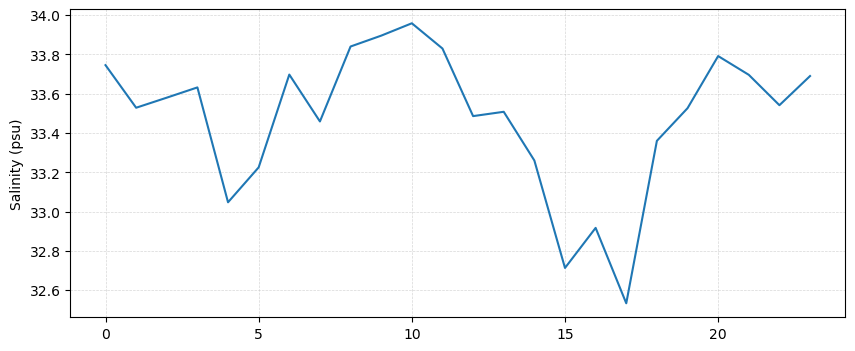

In [39]:
# make a figure of width 10 and height 4
plt.figure(figsize=(10,4))

# plot the timeseries
plt.plot(sss_values)

# label the y axis with the units
plt.ylabel('Salinity (psu)')

# add grid lines
plt.grid(linestyle='--',alpha=0.5,linewidth=0.5)

### Make the plot with the datetimes

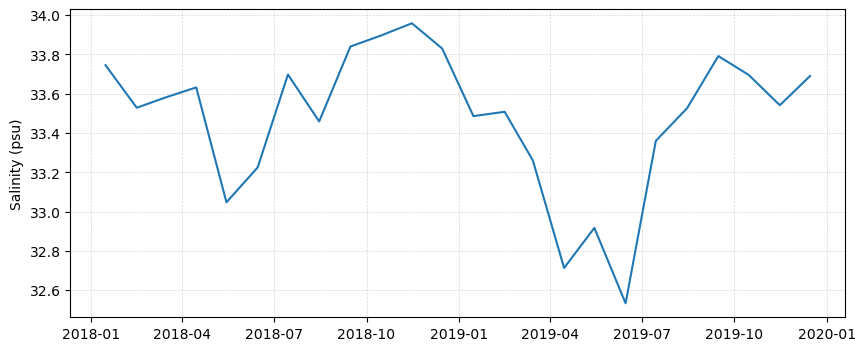

In [40]:
# make a figure of width 10 and height 4
plt.figure(figsize=(10,4))

# plot the timeseries
plt.plot(date_array,sss_values)

# label the y axis with the units
plt.ylabel('Salinity (psu)')

# add grid lines
plt.grid(linestyle='--',alpha=0.5,linewidth=0.5)